In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.metrics import silhouette_score

In [2]:
# =========================
# 1. Set paths
# =========================
save_dir = "/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/model_keeping_score/results_path3000"
broad_membership_csv = "/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/Interpretability/pathway_clustering/kNN_mean_outputs/broad_perturbation_membership_k6.csv"
perturbation_names_path = "/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/ExPert/anndata/splits/perturbation_names.npy"
y_test_path = "/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/ExPert/anndata/splits/y_test.npy"
mean_path = "/projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/datapoint_extraction/sample_mean/mean.npz"
analysis_dir = os.path.join(save_dir, "gene_heatmap_analysis_true_broad_k6")
permutation_dir = os.path.join(analysis_dir, "permutation_test_path3000")
# =========================

In [ ]:
# ============================================================
# Build the relative perturbation x latent matrix if needed
# - loads ll_comp.npy from results_path3000
# - averages over diffusion paths for each perturbation
# - aligns component rows through sample_mean/mean.npz labels
# - assigns the missing reference/control row to control explicitly
# ============================================================

def load_pickled_npy(path):
    # Older NumPy environments (for example scTAB_new) do not expose the
    # module path used when this object array was pickled.
    sys.modules.setdefault("numpy._core", np.core)
    sys.modules.setdefault("numpy._core.multiarray", np.core.multiarray)
    return np.load(path, allow_pickle=True)


def cluster_within_group(frame):
    if frame.shape[0] <= 2:
        return frame.index.tolist()
    dist = pdist(frame.to_numpy(), metric="euclidean")
    link = linkage(dist, method="ward")
    return frame.index[leaves_list(link)].tolist()


def convert_ll_comp_to_final_components(ll_comp, ll_final):
    if ll_comp.ndim == 3:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(
                f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}"
            )
        return ll_comp, "ll_comp interpreted as [G, P, D]"

    if ll_comp.ndim == 4:
        if ll_comp.shape[:2] != ll_final.shape:
            raise ValueError(
                f"ll_comp first two dims {ll_comp.shape[:2]} do not match ll_final {ll_final.shape}"
            )

        cand_last = ll_comp[:, :, -1, :]
        cand_sum = ll_comp.sum(axis=2)

        err_last = np.mean(np.abs(cand_last.sum(axis=-1) - ll_final))
        err_sum = np.mean(np.abs(cand_sum.sum(axis=-1) - ll_final))

        if err_last <= err_sum:
            return cand_last, f"ll_comp interpreted as [G, P, T, D], using final time slice (MAE={err_last:.3e})"
        return cand_sum, f"ll_comp interpreted as [G, P, T, D], summing over time (MAE={err_sum:.3e})"

    raise ValueError(f"Unsupported ll_comp shape: {ll_comp.shape}")


def align_component_rows(ll_comp_final, perturbation_names):
    """Return one component row per perturbation label.

    KeepingSCORE is run on sample_mean/mean.npz, which excludes control cells.
    The saved ll_comp rows therefore need to be aligned by the original labels
    in mean.npz instead of by position.  The only allowed missing row is the
    control reference row, which is inserted as the zero baseline.
    """
    n_perturbations = len(perturbation_names)
    if ll_comp_final.shape[0] == n_perturbations:
        return ll_comp_final, "ll_comp already has one row per perturbation"

    if "mean_path" not in globals():
        raise NameError("mean_path is not defined; set it to the sample_mean/mean.npz used for KeepingSCORE")

    mean_data = np.load(mean_path, allow_pickle=True)
    if "y" not in mean_data.files:
        raise KeyError(f"{mean_path} is missing the required 'y' array")

    component_labels = np.asarray(mean_data["y"]).astype(int)
    if component_labels.shape[0] != ll_comp_final.shape[0]:
        raise ValueError(
            f"ll_comp has {ll_comp_final.shape[0]} rows, but {mean_path} has "
            f"{component_labels.shape[0]} labels"
        )
    if len(np.unique(component_labels)) != len(component_labels):
        raise ValueError("mean_path labels are not unique; cannot align ll_comp rows unambiguously")
    if np.any((component_labels < 0) | (component_labels >= n_perturbations)):
        raise ValueError("mean_path labels fall outside perturbation_names.npy bounds")

    aligned = np.zeros((n_perturbations, *ll_comp_final.shape[1:]), dtype=ll_comp_final.dtype)
    filled = np.zeros(n_perturbations, dtype=bool)
    aligned[component_labels] = ll_comp_final
    filled[component_labels] = True

    missing_idx = np.where(~filled)[0]
    missing_names = perturbation_names[missing_idx].astype(str).tolist()
    if missing_names != ["control"]:
        raise ValueError(
            "Only the control row may be absent from KeepingSCORE component outputs; "
            f"missing rows are {missing_names}"
        )

    print(
        "Aligned ll_comp rows using mean_path labels; inserted zero baseline for "
        f"missing control reference row at index {int(missing_idx[0])}."
    )
    return aligned, "ll_comp rows aligned by sample_mean labels"


def resolve_reference_index(ref_gene, perturbation_names):
    if isinstance(ref_gene, (int, np.integer)):
        ref_idx = int(ref_gene)
        if ref_idx < 0 or ref_idx >= len(perturbation_names):
            raise ValueError(f"ref_gene index {ref_idx} is out of bounds for {len(perturbation_names)} perturbations")
        return ref_idx

    if isinstance(ref_gene, str):
        matches = np.where(perturbation_names == ref_gene)[0]
        if len(matches) == 0:
            raise ValueError(f"ref_gene '{ref_gene}' was not found in perturbation_names.npy")
        return int(matches[0])

    raise TypeError("ref_gene must be either an integer perturbation index or a gene symbol string")


def build_relative_heatmap_df(save_dir, ref_gene, top_k_dims):
    ll_comp_path = os.path.join(save_dir, "ll_comp.npy")
    ll_final_path = os.path.join(save_dir, "ll_final.npy")
    perturbation_names = load_pickled_npy(perturbation_names_path).astype(str)
    y_test = np.load(y_test_path)
    ll_final = np.load(ll_final_path)
    ll_comp = np.load(ll_comp_path)
    ll_comp_final, comp_msg = convert_ll_comp_to_final_components(ll_comp, ll_final)
    print(comp_msg)
    annotations = pd.read_csv(broad_membership_csv).copy()

    ll_comp_final, align_msg = align_component_rows(ll_comp_final, perturbation_names)
    print(align_msg)

    if "perturbation_plot" in annotations.columns and "gene" not in annotations.columns:
        annotations = annotations.rename(columns={"perturbation_plot": "gene"})
    if "broad_cluster" in annotations.columns and "broad_level_perturbation_type" not in annotations.columns:
        annotations["broad_level_perturbation_type"] = "k6_cluster_" + annotations["broad_cluster"].astype(str)

    required_cols = {"gene", "broad_level_perturbation_type"}
    missing_cols = required_cols.difference(annotations.columns)
    if missing_cols:
        raise ValueError(f"Annotation file is missing required columns: {sorted(missing_cols)}")

    annotations["gene"] = annotations["gene"].astype(str)
    missing_genes = sorted(set(perturbation_names) - set(annotations["gene"]))
    if missing_genes:
        placeholder_rows = pd.DataFrame({
            col: ("control" if col == "gene" else "k6_cluster_control" if col == "broad_level_perturbation_type" else "")
            for col in annotations.columns
        }, index=range(len(missing_genes)))
        placeholder_rows["gene"] = missing_genes
        annotations = pd.concat([annotations, placeholder_rows], ignore_index=True)

    gene_profiles = ll_comp_final.mean(axis=1)
    gene_counts = np.bincount(y_test.astype(int), minlength=len(perturbation_names)).tolist()

    ref_idx = resolve_reference_index(ref_gene, perturbation_names)
    ref_gene_name = str(perturbation_names[ref_idx])
    ref_profile = gene_profiles[ref_idx].copy()
    gene_profiles_rel = gene_profiles - ref_profile[None, :]

    dim_var = gene_profiles_rel.var(axis=0)
    keep_idx = np.argsort(-dim_var)[: min(top_k_dims, gene_profiles_rel.shape[1])]
    latent_names = [f"z{j}" for j in keep_idx]

    df_heat = pd.DataFrame(gene_profiles_rel[:, keep_idx], index=perturbation_names, columns=latent_names)

    annotation_df = annotations[["gene", "broad_level_perturbation_type"]].copy()
    annotation_df = annotation_df.set_index("gene").loc[list(perturbation_names)].reset_index()
    annotation_df["sample_count"] = gene_counts
    annotation_df.index = annotation_df["gene"]

    return df_heat, keep_idx, annotation_df, ref_idx, ref_gene_name, ll_comp_final.shape

ref_gene = globals().get("ref_gene", "control")
top_k_dims = globals().get("top_k_dims", 200)
# display_vmin = globals().get("display_vmin", -1.5)
# display_vmax = globals().get("display_vmax", 1.5)

if not os.path.isabs(save_dir):
    save_dir = os.path.abspath(save_dir)

df_heat_broad, keep_idx_broad, annotation_df, ref_idx, ref_gene_name, true_comp_shape = build_relative_heatmap_df(
    save_dir=save_dir,
    ref_gene=ref_gene,
    top_k_dims=top_k_dims,
)

annotation_df = annotation_df.loc[df_heat_broad.index].copy()
center_label = f"relative_to_{ref_gene_name}"
cbar_label = f"mean true ll across paths minus {ref_gene_name}"

print("ll_comp-derived component shape:", true_comp_shape)
print("gene-level matrix shape:", df_heat_broad.shape)
print(f"Reference perturbation: {ref_gene_name} (index {ref_idx})")
print(annotation_df["broad_level_perturbation_type"].value_counts())


ll_comp interpreted as [G, P, D]
ll_comp already has one row per perturbation
ll_comp-derived component shape: (98, 3000, 384)
gene-level matrix shape: (98, 200)
Reference perturbation: control (index 97)
broad_level_perturbation_type
k6_cluster_0    36
k6_cluster_1    32
k6_cluster_2    30
Name: count, dtype: int64


/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


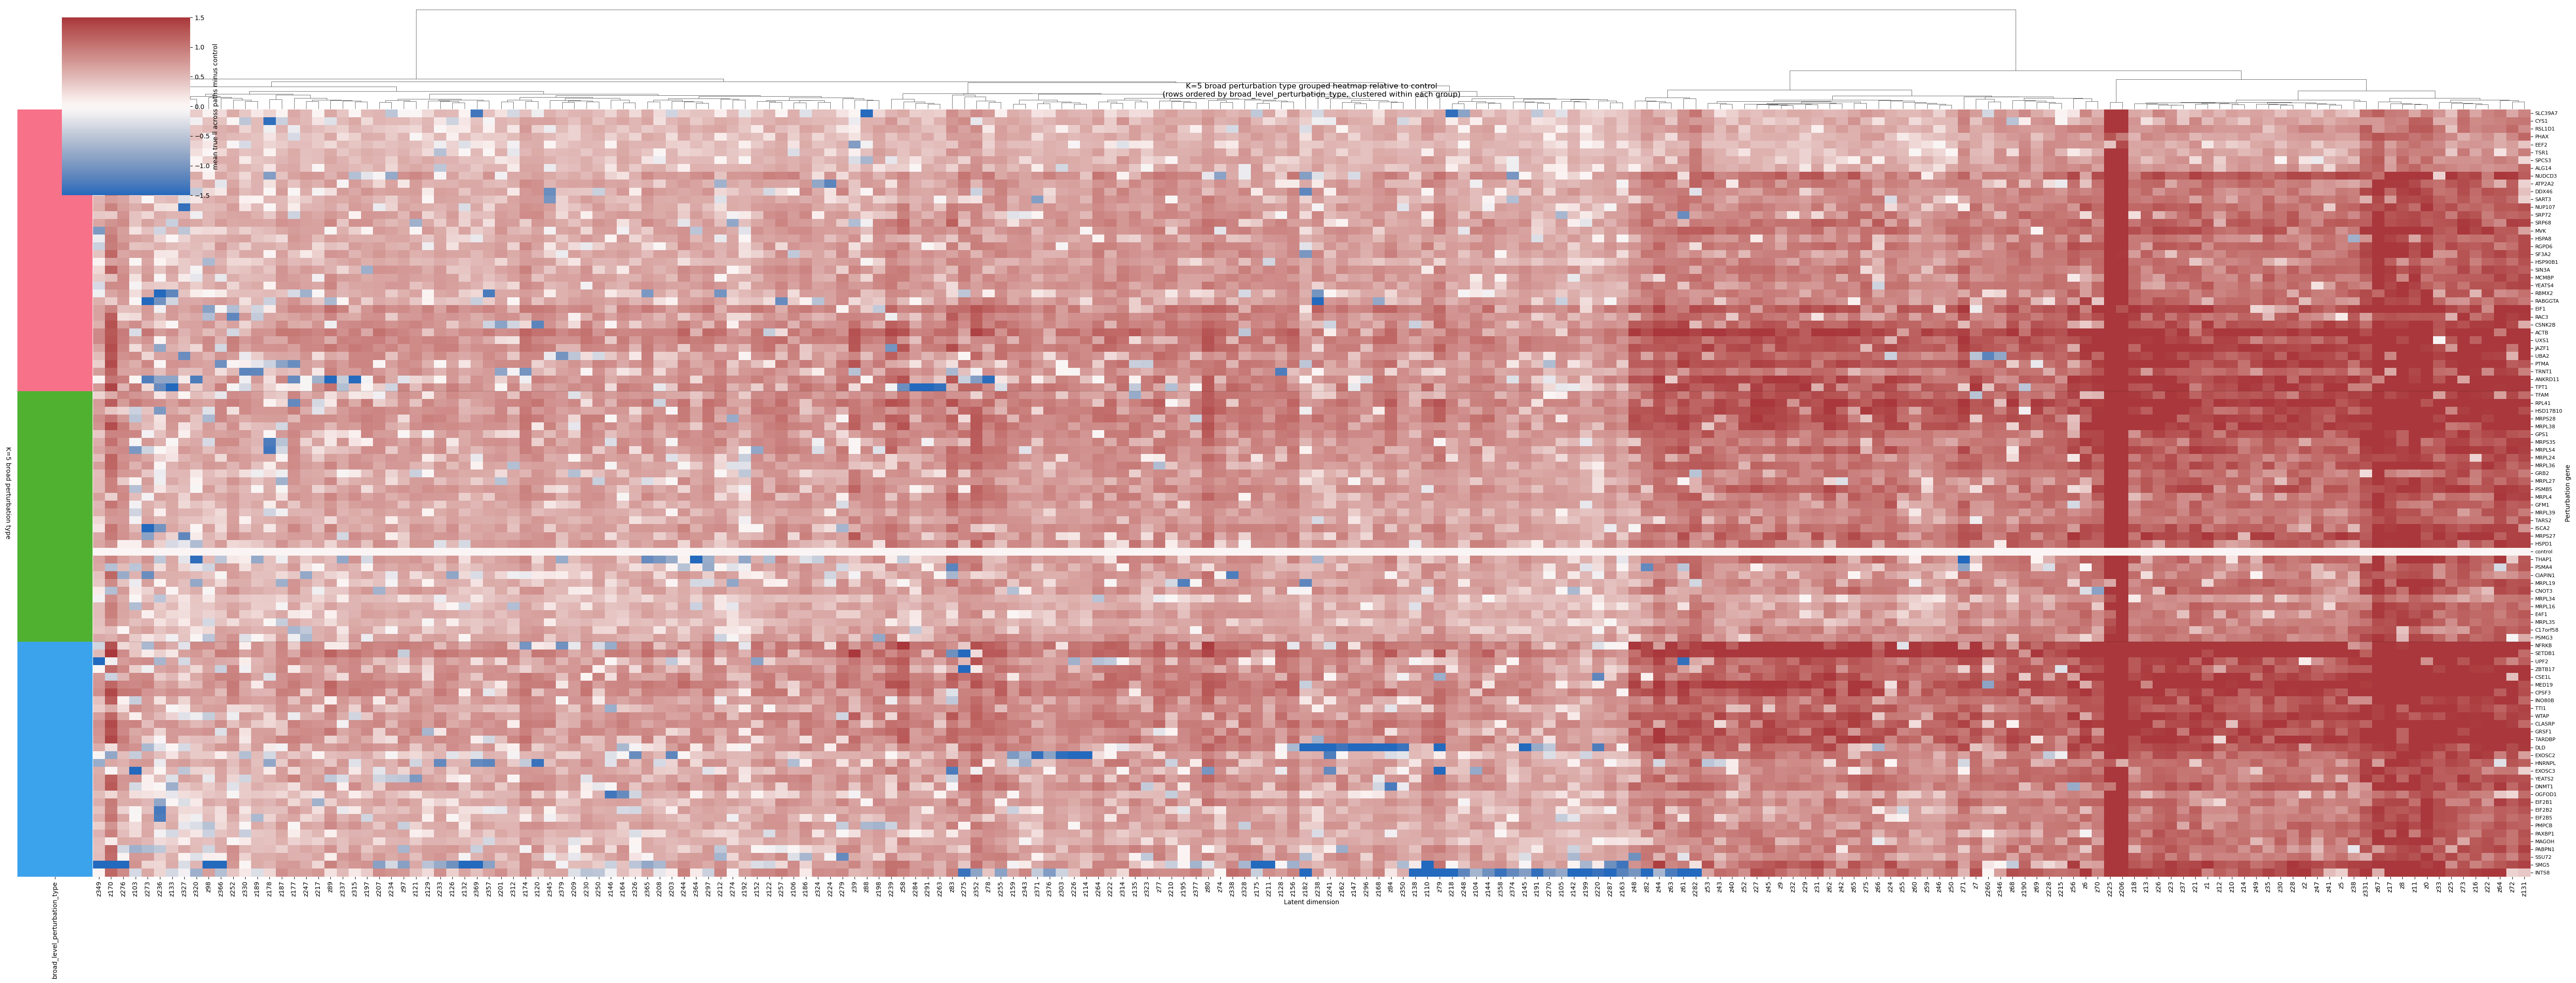

In [ ]:
# ============================================================
# Broad-category grouping for the relative perturbation heatmap
# - orders rows by broad category, then clusters within each group
# - keeps row blocks fixed so the grouping is preserved in the plot
# ============================================================

ref_gene = globals().get("ref_gene", "control")
# display_vmin = globals().get("display_vmin", -1.5)
# display_vmax = globals().get("display_vmax", 1.5)

if not os.path.isabs(save_dir):
    save_dir = os.path.abspath(save_dir)

if "df_heat_broad" not in globals() or "annotation_df" not in globals():
    raise RuntimeError("Run the matrix-building cell first so df_heat_broad and annotation_df are available.")

ordered_index = []
group_boundaries = []
group_labels = annotation_df["broad_level_perturbation_type"].astype(str).copy()
category_order = list(pd.unique(group_labels))

for broad_level in category_order:
    members = annotation_df.index[annotation_df["broad_level_perturbation_type"] == broad_level]
    ordered_members = cluster_within_group(df_heat_broad.loc[members])
    ordered_index.extend(ordered_members)
    group_boundaries.append(len(ordered_index))

df_grouped = df_heat_broad.loc[ordered_index].copy()
row_annotations_grouped = annotation_df.loc[ordered_index].copy()
original_labels = row_annotations_grouped["gene"].astype(str).values

all_categories = sorted(annotation_df["broad_level_perturbation_type"].astype(str).unique())
palette = sns.color_palette("husl", n_colors=len(all_categories))
group_to_color = dict(zip(all_categories, palette))

row_colors = row_annotations_grouped["broad_level_perturbation_type"].map(group_to_color)

g = sns.clustermap(
    df_grouped,
    cmap="vlag",
    center=0,
    vmin=display_vmin,
    vmax=display_vmax,
    row_cluster=False,
    col_cluster=True,
    row_colors=row_colors,
    metric="euclidean",
    method="ward",
    xticklabels=True,
    yticklabels=True,
    figsize=(max(15, 0.28 * df_grouped.shape[1]), max(12, 0.22 * df_grouped.shape[0])),
    dendrogram_ratio=(0.0, 0.12),
    cbar_kws={"label": cbar_label}
)

for boundary in group_boundaries[:-1]:
    g.ax_heatmap.hlines(boundary, *g.ax_heatmap.get_xlim(), colors="black", linewidth=0.35, alpha=0.35)

g.ax_heatmap.set_yticklabels(original_labels, fontsize=8)
g.ax_heatmap.set_title(
    f"K=5 broad perturbation type grouped heatmap relative to {ref_gene_name}\n(rows ordered by broad_level_perturbation_type, clustered within each group)",
    pad=20
)
g.ax_heatmap.set_xlabel("Latent dimension")
g.ax_heatmap.set_ylabel("Perturbation gene")
g.ax_row_colors.set_ylabel("K=5 broad perturbation type", rotation=270, labelpad=20)

os.makedirs(analysis_dir, exist_ok=True)
grouped_png = os.path.join(analysis_dir, f"gene_grouped_k6_true_ll_heatmap_top{df_grouped.shape[1]}_{center_label}.png")
g.fig.savefig(grouped_png, dpi=300, bbox_inches="tight")
plt.show()


/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/projects/b1042/GoyalLab/jaekj/python/KS_perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


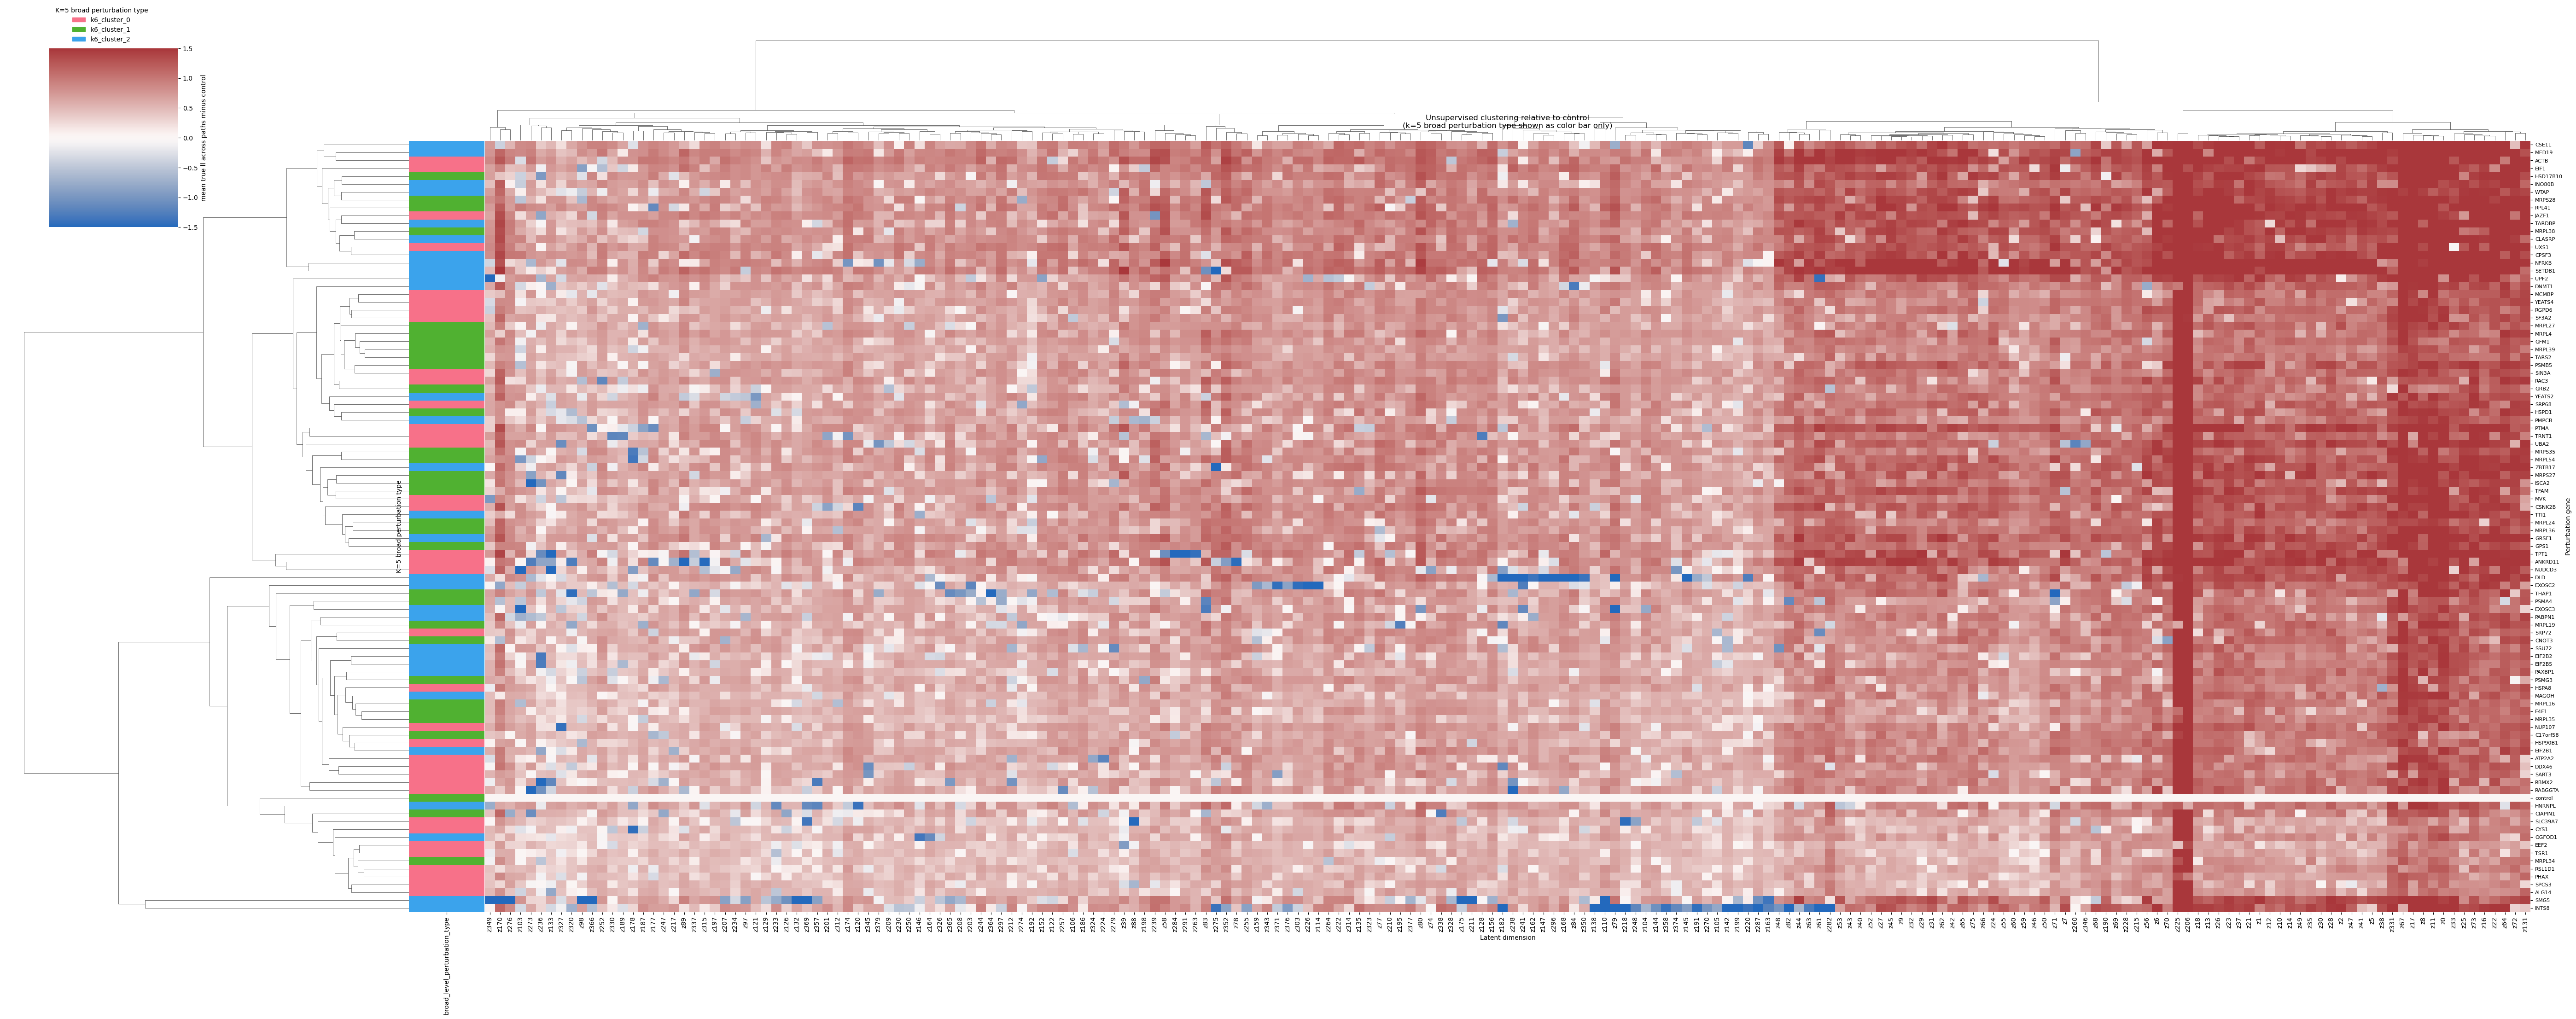

In [ ]:
# ============================================
# TRUE unsupervised clustering + annotations
# ============================================

# Keep original labels (perturbation genes)
df_plot = df_heat_broad.copy()

# Build annotations
row_annotations = pd.DataFrame(
    {
        "gene": annotation_df.loc[df_plot.index, "gene"].astype(str).values,
        "broad_level_perturbation_type": annotation_df.loc[df_plot.index, "broad_level_perturbation_type"].astype(str).values,
    },
    index=df_plot.index,
)

# Color bar for unsupervised k=5 broad perturbation types
palette = sns.color_palette("husl", n_colors=len(np.unique(row_annotations["broad_level_perturbation_type"])))
group_to_color = dict(zip(sorted(np.unique(row_annotations["broad_level_perturbation_type"])), palette))
row_colors = row_annotations["broad_level_perturbation_type"].map(group_to_color)

vmin = np.nanmin(df_plot.values)
vmax = np.nanmax(df_plot.values)

# --- CLUSTERMAP ---
g = sns.clustermap(
    df_plot,
    cmap="vlag",
    center=None, #0,
    vmin=vmin,
    vmax=vmax,
    row_cluster=True,
    col_cluster=True,
    row_colors=row_colors,
    metric="euclidean",
    method="ward",
    xticklabels=True,
    yticklabels=True,
    figsize=(max(15, 0.28 * df_plot.shape[1]), max(12, 0.22 * df_plot.shape[0])),
    dendrogram_ratio=(0.16, 0.12),
    cbar_kws={"label": cbar_label}
)

legend_handles = [
    mpatches.Patch(color=group_to_color[group], label=group)
    for group in sorted(group_to_color.keys())
]

g.fig.legend(
    handles=legend_handles,
    title="K=5 broad perturbation type",
    loc="lower left",
    bbox_to_anchor=(0.02, 0.98),
    frameon=False
)

row_order = g.dendrogram_row.reordered_ind
ordered_labels = row_annotations.iloc[row_order]["gene"].values

g.ax_heatmap.set_yticklabels(ordered_labels, fontsize=8)
g.ax_heatmap.set_title(
    f"Unsupervised clustering relative to {ref_gene_name}\n(k=5 broad perturbation type shown as color bar only)",
    pad=20
)
g.ax_heatmap.set_xlabel("Latent dimension")
g.ax_heatmap.set_ylabel("Perturbation gene")
g.ax_row_colors.set_ylabel("K=5 broad perturbation type", rotation=90, labelpad=10)
g.ax_row_colors.yaxis.set_label_position("left")
g.ax_row_colors.yaxis.tick_left()

unsup_png = os.path.join(analysis_dir, f"gene_unsupervised_k6_true_ll_heatmap_top{df_plot.shape[1]}_{center_label}.png")
g.fig.savefig(unsup_png, dpi=300, bbox_inches="tight")
plt.show()

### Permutation test


In [6]:
# ============================================
# Use CLUSTERED order (CRITICAL FIX)
# ============================================

# Get clustering order
row_order = g.dendrogram_row.reordered_ind

# Reorder matrix and labels
X = df_plot.iloc[row_order].copy()
print("Mean of matrix (should be ~0):", X.mean())

labels = row_annotations.iloc[row_order]["broad_level_perturbation_type"].values

print("Using clustered row order")
print("Matrix shape:", X.shape)


Mean of matrix (should be ~0): z170    0.759764
z138    0.498388
z349    0.315348
z276    0.559962
z110    0.606763
          ...   
z37     1.110471
z75     0.935446
z250    0.574137
z59     0.785242
z28     1.087960
Length: 200, dtype: float32
Using clustered row order
Matrix shape: (98, 200)


In [7]:
# ============================================
# Pairwise Euclidean distances (precompute)
# ============================================

dist_vec = pdist(X, metric="euclidean")
dist_mat = squareform(dist_vec)

print("Distance matrix shape:", dist_mat.shape)


Distance matrix shape: (98, 98)


In [8]:
# ============================================
# Compute within / between distances
# ============================================

def compute_within_between(dist_mat, labels):
    """
    Returns:
        mean_within, mean_between
    """
    labels = np.asarray(labels)

    same = labels[:, None] == labels[None, :]
    diff = ~same

    np.fill_diagonal(same, False)
    np.fill_diagonal(diff, False)

    within_vals = dist_mat[same]
    between_vals = dist_mat[diff]

    return within_vals.mean(), between_vals.mean()


In [9]:
# ============================================
# Observed (non-randomized)
# ============================================

mean_w_obs, mean_b_obs = compute_within_between(dist_mat, labels)
delta_obs = mean_b_obs - mean_w_obs

print("Observed:")
print("  <r_ij>_w =", mean_w_obs)
print("  <r_ij>_b =", mean_b_obs)
print("  delta    =", delta_obs)


Observed:
  <r_ij>_w = 7.102190455222516
  <r_ij>_b = 7.253143261426313
  delta    = 0.15095280620379725


In [10]:
# ============================================
# Permutation test
# ============================================

n_perm = 100_000

mean_w_list = []
mean_b_list = []
delta_list = []

rng = np.random.default_rng(seed=42)

for i in range(n_perm):
    shuffled_labels = rng.permutation(labels)

    mw, mb = compute_within_between(dist_mat, shuffled_labels)

    mean_w_list.append(mw)
    mean_b_list.append(mb)
    delta_list.append(mb - mw)

    if i % 200 == 0:
        print(f"Permutation {i}/{n_perm}")

mean_w_arr = np.array(mean_w_list)
mean_b_arr = np.array(mean_b_list)
delta_arr = np.array(delta_list)


Permutation 0/100000
Permutation 200/100000
Permutation 400/100000
Permutation 600/100000
Permutation 800/100000
Permutation 1000/100000
Permutation 1200/100000
Permutation 1400/100000
Permutation 1600/100000
Permutation 1800/100000
Permutation 2000/100000
Permutation 2200/100000
Permutation 2400/100000
Permutation 2600/100000
Permutation 2800/100000
Permutation 3000/100000
Permutation 3200/100000
Permutation 3400/100000
Permutation 3600/100000
Permutation 3800/100000
Permutation 4000/100000
Permutation 4200/100000
Permutation 4400/100000
Permutation 4600/100000
Permutation 4800/100000
Permutation 5000/100000
Permutation 5200/100000
Permutation 5400/100000
Permutation 5600/100000
Permutation 5800/100000
Permutation 6000/100000
Permutation 6200/100000
Permutation 6400/100000
Permutation 6600/100000
Permutation 6800/100000
Permutation 7000/100000
Permutation 7200/100000
Permutation 7400/100000
Permutation 7600/100000
Permutation 7800/100000
Permutation 8000/100000
Permutation 8200/100000

In [11]:
# ============================================
# Save results
# ============================================

os.makedirs(permutation_dir, exist_ok=True)

np.save(os.path.join(permutation_dir, "mean_within.npy"), mean_w_arr)
np.save(os.path.join(permutation_dir, "mean_between.npy"), mean_b_arr)
np.save(os.path.join(permutation_dir, "delta.npy"), delta_arr)

summary = {
    "reference_gene": ref_gene_name,
    "reference_index": int(ref_idx),
    "center_label": center_label,
    "top_k_dims": int(df_plot.shape[1]),
    "n_perm": int(n_perm),
    "mean_within_observed": float(mean_w_obs),
    "mean_between_observed": float(mean_b_obs),
    "delta_observed": float(delta_obs),
}

with open(os.path.join(permutation_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved permutation results to:", permutation_dir)


Saved permutation results to: /projects/b1042/GoyalLab/jaekj/KeepingScore/perturb-seq/model_keeping_score/results_path3000/gene_heatmap_analysis_true_broad_k6/permutation_test_path3000


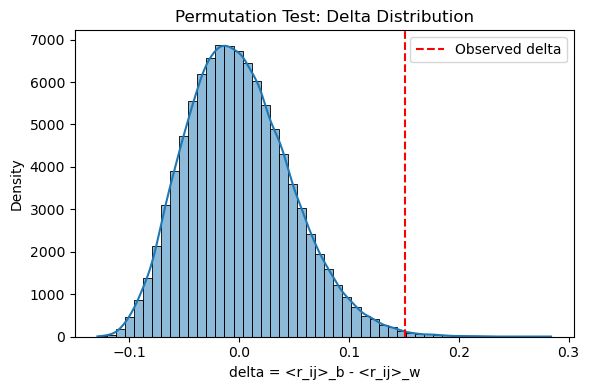

In [12]:
# ============================================
# Plot delta distribution
# ============================================

plt.figure(figsize=(6, 4))

sns.histplot(delta_arr, bins=50, kde=True)

plt.axvline(delta_obs, color="red", linestyle="--", label="Observed delta")

plt.xlabel("delta = <r_ij>_b - <r_ij>_w")
plt.ylabel("Density")
plt.title("Permutation Test: Delta Distribution")
plt.legend()

plt.tight_layout()
delta_png = os.path.join(permutation_dir, "delta_distribution.png")
plt.savefig(delta_png, dpi=300, bbox_inches="tight")
plt.show()


In [13]:
# ============================================
# p-value computation
# ============================================

# One-sided (between > within)
p_value = (np.sum(delta_arr >= delta_obs) + 1) / (n_perm + 1)

# Two-sided (optional)
p_value_two_sided = (np.sum(np.abs(delta_arr) >= np.abs(delta_obs)) + 1) / (n_perm + 1)

summary.update(
    {
        "p_value_one_sided": float(p_value),
        "p_value_two_sided": float(p_value_two_sided),
    }
)
with open(os.path.join(permutation_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("P-value (one-sided):", p_value)
print("P-value (two-sided):", p_value_two_sided)


P-value (one-sided): 0.003229967700322997
P-value (two-sided): 0.003229967700322997


### Silhouette score


In [14]:
score = silhouette_score(X, labels, metric="euclidean")
summary["silhouette_score"] = float(score)
with open(os.path.join(permutation_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Silhouette score:", score)

Silhouette score: -0.035585664212703705


In [15]:
scores_perm = []

n_perm_shil = 1000
for i in range(n_perm_shil):
    shuffled = np.random.permutation(labels)
    s = silhouette_score(X, shuffled, metric="euclidean")
    scores_perm.append(s)

scores_perm = np.array(scores_perm)

p_val = np.mean(scores_perm >= score)
summary["silhouette_p_value"] = float(p_val)
with open(os.path.join(permutation_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print("Permutation p-value (silhouette):", p_val)


Permutation p-value (silhouette): 0.841
